## What is this project about?

This project demonstrates how to build a Multi-Modal Retrieval Augmented Generation (RAG) pipeline using a PDF document that contains text, images, tables, and structured sections.

Instead of treating a PDF as plain text, we:

* Break it into meaningful elements (titles, paragraphs, tables, images)

* Organize those elements into logical chunks

* Store those chunks in a vector database

* Retrieve the most relevant information when a user asks a question

This approach allows Large Language Models (LLMs) to answer questions more accurately using external documents, rather than relying only on their training data.



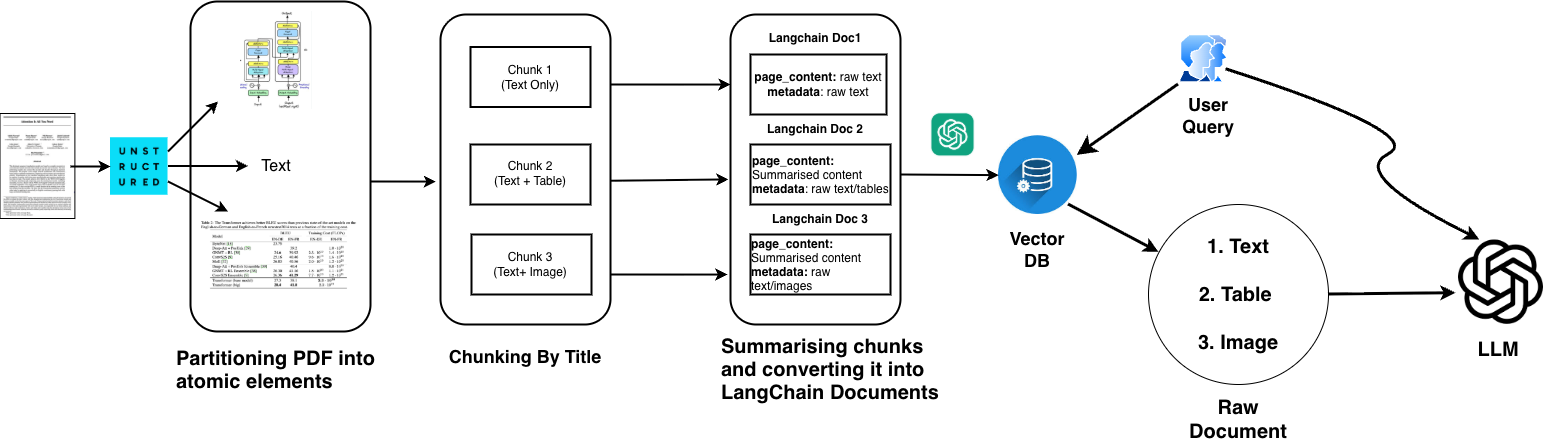

## System Dependencies

To get started with Unstructured.io, we need a few system-wide dependencies:

### Poppler (poppler-utils)
Handles PDF processing. It's a library that can extract text, images, and metadata from PDFs. Unstructured uses it to parse PDF documents and convert them into processable text.

### Tesseract (tesseract-ocr)
Optical Character Recognition (OCR) engine. When you have scanned documents, images with text, or PDFs that are essentially pictures, Tesseract reads the text from these images and converts it to machine-readable text.

### libmagic
File type detection library. It identifies what type of file you're dealing with (PDF, Word doc, image, etc.) by analyzing the file's content, not just the extension. This helps Unstructured choose the right processing method for each document.

In [ ]:
# for linux
!apt-get install poppler-utils tesseract-ocr libmagic-dev

Reading package lists... Done
^C


In [ ]:
from openai import OpenAI
from google.colab import userdata
import os
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

In [ ]:
%pip install -Uq "unstructured[all-docs]"
%pip install -Uq langchain_chroma
%pip install -Uq langchain langchain-community langchain-openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 49.8 MB/s eta 0:00:00
   

In [ ]:
import json
from typing import List

# Unstructured for document parsing
from unstructured.partition.pdf import partition_pdf
from unstructured.chunking.title import chunk_by_title

# LangChain components
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.messages import HumanMessage

## Document Partitioning
**What does “partitioning” mean?**

Partitioning breaks a document into elements, such as:

* Titles

* Paragraphs

* Lists

* Tables

* Images

* Page headers/footers

Instead of one long block of text, we get structured components.

**Why is this important?**

* Improves retrieval accuracy

* Preserves document meaning

* Allows separate handling of text, tables, and images

This is done using the `partition_pdf()` function.

In [ ]:
def partition_document(file_path: str):
    """Extract elements from PDF using unstructured"""
    print(f"📄 Partitioning document: {file_path}")

    elements = partition_pdf(
        filename=file_path,  # Path to your PDF file
        strategy="hi_res", # Use the most accurate (but slower) processing method of extraction
        infer_table_structure=True, # Keep tables as structured HTML, not jumbled text
        extract_image_block_types=["Image"], # Grab images found in the PDF
        extract_image_block_to_payload=True # Store images as base64 data you can actually use
    )

    print(f"Extracted {len(elements)} elements")
    return elements

# Test with your PDF file
file_path = "/content/attention-is-all-you-need.pdf"  # Change this to your PDF path
elements = partition_document(file_path)

📄 Partitioning document: /content/attention-is-all-you-need.pdf


preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Extracted 212 elements


In [ ]:
# elements
# len(elements)

elements

In [ ]:
# All types of different elements we see from unstructured
set([str(type(el)) for el in elements])

{"<class 'unstructured.documents.elements.FigureCaption'>",
 "<class 'unstructured.documents.elements.Footer'>",
 "<class 'unstructured.documents.elements.Formula'>",
 "<class 'unstructured.documents.elements.Header'>",
 "<class 'unstructured.documents.elements.Image'>",
 "<class 'unstructured.documents.elements.ListItem'>",
 "<class 'unstructured.documents.elements.NarrativeText'>",
 "<class 'unstructured.documents.elements.Table'>",
 "<class 'unstructured.documents.elements.Text'>",
 "<class 'unstructured.documents.elements.Title'>"}

In [ ]:
elements[40].to_dict()

{'type': 'NarrativeText',
 'element_id': 'f10ff8d14bf19398154d70fe639e6005',
 'text': 'Self-attention, sometimes called intra-attention is an attention mechanism relating different positions of a single sequence in order to compute a representation of the sequence. Self-attention has been used successfully in a variety of tasks including reading comprehension, abstractive summarization, textual entailment and learning task-independent sentence representations [4, 27, 28, 22].',
 'metadata': {'detection_class_prob': 0.9446496963500977,
  'is_extracted': 'true',
  'coordinates': {'points': ((np.float64(295.12493896484375),
     np.float64(1368.9175599999999)),
    (np.float64(295.12493896484375), np.float64(1487.4997822222222)),
    (np.float64(1413.9830322265625), np.float64(1487.4997822222222)),
    (np.float64(1413.9830322265625), np.float64(1368.9175599999999))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2026-01-27T18:17:45',
 

In [ ]:
# Gather all images
images = [element for element in elements if element.category == 'Image']
print(f"Found {len(images)} images")

images[0].to_dict()

# Use https://codebeautify.org/base64-to-image-converter to view the base64 text

Found 7 images


{'type': 'Image',
 'element_id': '6f5f5a92fc9fea5732681d6b267bf0a8',
 'text': 'Output Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention Add & Norm Masked Multi-Head Attention Add & Norm Feed Forward Add & Norm Multi-Head Attention Nx Positional Encoding O° Positional @ OY Encoding Input Output Embedding Embedding Inputs Outputs (shifted right)',
 'metadata': {'coordinates': {'points': ((np.float64(545.9972222222221),
     np.float64(200.00555555555542)),
    (np.float64(545.9972222222221), np.float64(1095.6055555555556)),
    (np.float64(1153.997222222222), np.float64(1095.6055555555556)),
    (np.float64(1153.997222222222), np.float64(200.00555555555542))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2026-01-27T18:17:45',
  'filetype': 'application/pdf',
  'languages': ['eng'],
  'page_number': 3,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg',
  'file_directory': '/content',
  'filename': 'attentio

In [ ]:
# Gather all table
tables = [element for element in elements if element.category == 'Table']
print(f"Found {len(tables)} tables")

tables[0].to_dict()

# Use https://jsfiddle.net/ to view the table html


Found 4 tables


{'type': 'Table',
 'element_id': 'a89281d85d3d589d6b9b2c889815cbce',
 'text': 'Layer Type Complexity per Layer Sequential Maximum Path Length Operations Self-Attention O(n2 · d) O(1) O(1) Recurrent O(n · d2) O(n) O(n) Convolutional O(k · n · d2) O(1) O(logk(n)) Self-Attention (restricted) O(r · n · d) O(1) O(n/r)',
 'metadata': {'detection_class_prob': 0.9281636476516724,
  'is_extracted': 'true',
  'coordinates': {'points': ((np.float64(320.2978210449219),
     np.float64(314.02044677734375)),
    (np.float64(320.2978210449219), np.float64(519.3817138671875)),
    (np.float64(1367.6617431640625), np.float64(519.3817138671875)),
    (np.float64(1367.6617431640625), np.float64(314.02044677734375))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2026-01-27T18:17:45',
  'text_as_html': '<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>

In [ ]:
def create_chunks_by_title(elements):
    """Create intelligent chunks using title-based strategy"""
    print("Creating smart chunks...")

    chunks = chunk_by_title(
        elements, # The parsed PDF elements from previous step
        max_characters=3000, # Hard limit - never exceed 3000 characters per chunk
        new_after_n_chars=2400, # Try to start a new chunk after 2400 characters
        combine_text_under_n_chars=500 # Merge tiny chunks under 500 chars with neighbors
    )

    print(f"Created {len(chunks)} chunks")
    return chunks

# Create chunks
chunks = create_chunks_by_title(elements)

Creating smart chunks...
Created 25 chunks


In [ ]:
# View all chunks
chunks

In [ ]:
# All unique types
set([str(type(chunk)) for chunk in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [ ]:
# View a single chunk
chunks[2].to_dict()

{'type': 'CompositeElement',
 'element_id': 'b477b5e0-9ab5-460b-973a-f79fab67848f',
 'text': '1 Introduction\n\nRecurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation [35, 2, 5]. Numerous efforts have since continued to push the boundaries of recurrent language models and encoder-decoder architectures [38, 24, 15].\n\nRecurrent models typically factor computation along the symbol positions of the input and output sequences. Aligning the positions to steps in computation time, they generate a sequence of hidden states ht, as a function of the previous hidden state ht−1 and the input for position t. This inherently sequential nature precludes parallelization within training examples, which becomes critical at longer sequence lengths, as memory constraints limit batching across ex

In [ ]:
# View original elements
chunks[11].metadata.orig_elements[-1].to_dict()
# Note: 4th chunk has the first image + 11th chunk has the first table in the sample PDF

{'type': 'Table',
 'element_id': 'a89281d85d3d589d6b9b2c889815cbce',
 'text': 'Layer Type Complexity per Layer Sequential Maximum Path Length Operations Self-Attention O(n2 · d) O(1) O(1) Recurrent O(n · d2) O(n) O(n) Convolutional O(k · n · d2) O(1) O(logk(n)) Self-Attention (restricted) O(r · n · d) O(1) O(n/r)',
 'metadata': {'detection_class_prob': 0.9281636476516724,
  'is_extracted': 'true',
  'coordinates': {'points': ((np.float64(320.2978210449219),
     np.float64(314.02044677734375)),
    (np.float64(320.2978210449219), np.float64(519.3817138671875)),
    (np.float64(1367.6617431640625), np.float64(519.3817138671875)),
    (np.float64(1367.6617431640625), np.float64(314.02044677734375))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2026-01-27T18:17:45',
  'text_as_html': '<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>

In [ ]:
def separate_content_types(chunk):
    """Analyze what types of content are in a chunk"""
    content_data = {
        'text': chunk.text,
        'tables': [],
        'images': [],
        'types': ['text']
    }

    # Check for tables and images in original elements
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for element in chunk.metadata.orig_elements:
            element_type = type(element).__name__

            # Handle tables
            if element_type == 'Table':
                content_data['types'].append('table')
                table_html = getattr(element.metadata, 'text_as_html', element.text)
                content_data['tables'].append(table_html)

            # Handle images
            elif element_type == 'Image':
                if hasattr(element, 'metadata') and hasattr(element.metadata, 'image_base64'):
                    content_data['types'].append('image')
                    content_data['images'].append(element.metadata.image_base64)

    content_data['types'] = list(set(content_data['types']))
    return content_data

def create_ai_enhanced_summary(text: str, tables: List[str], images: List[str]) -> str:
    """Create AI-enhanced summary for mixed content"""

    try:
        # Initialize LLM (needs vision model for images)
        llm = ChatOpenAI(model="gpt-4o", temperature=0)

        # Build the text prompt
        prompt_text = f"""You are creating a searchable description for document content retrieval.

        CONTENT TO ANALYZE:
        TEXT CONTENT:
        {text}

        """

        # Add tables if present
        if tables:
            prompt_text += "TABLES:\n"
            for i, table in enumerate(tables):
                prompt_text += f"Table {i+1}:\n{table}\n\n"

                prompt_text += """
                YOUR TASK:
                Generate a comprehensive, searchable description that covers:

                1. Key facts, numbers, and data points from text and tables
                2. Main topics and concepts discussed
                3. Questions this content could answer
                4. Visual content analysis (charts, diagrams, patterns in images)
                5. Alternative search terms users might use

                Make it detailed and searchable - prioritize findability over brevity.

                SEARCHABLE DESCRIPTION:"""

        # Build message content starting with text
        message_content = [{"type": "text", "text": prompt_text}]

        # Add images to the message
        for image_base64 in images:
            message_content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
            })

        # Send to AI and get response
        message = HumanMessage(content=message_content)
        response = llm.invoke([message])

        return response.content

    except Exception as e:
        print(f"AI summary failed: {e}")
        # Fallback to simple summary
        summary = f"{text[:300]}..."
        if tables:
            summary += f" [Contains {len(tables)} table(s)]"
        if images:
            summary += f" [Contains {len(images)} image(s)]"
        return summary

def summarise_chunks(chunks):
    """Process all chunks with AI Summaries"""
    print("Processing chunks with AI Summaries...")

    langchain_documents = []
    total_chunks = len(chunks)

    for i, chunk in enumerate(chunks):
        current_chunk = i + 1
        print(f"Processing chunk {current_chunk}/{total_chunks}")

        # Analyze chunk content
        content_data = separate_content_types(chunk)

        # Debug prints
        print(f"Types found: {content_data['types']}")
        print(f"Tables: {len(content_data['tables'])}, Images: {len(content_data['images'])}")

        # Create AI-enhanced summary if chunk has tables/images
        if content_data['tables'] or content_data['images']:
            print(f"→Creating AI summary for mixed content...")
            try:
                enhanced_content = create_ai_enhanced_summary(
                    content_data['text'],
                    content_data['tables'],
                    content_data['images']
                )
                print(f"→ AI summary created successfully")
                print(f"→ Enhanced content preview: {enhanced_content[:200]}...")
            except Exception as e:
                print(f"AI summary failed: {e}")
                enhanced_content = content_data['text']
        else:
            print(f"→ Using raw text (no tables/images)")
            enhanced_content = content_data['text']

        # Create LangChain Document with rich metadata
        doc = Document(
            page_content=enhanced_content,
            metadata={
                "original_content": json.dumps({
                    "raw_text": content_data['text'],
                    "tables_html": content_data['tables'],
                    "images_base64": content_data['images']
                })
            }
        )

        langchain_documents.append(doc)

    print(f"Processed {len(langchain_documents)} chunks")
    return langchain_documents


# Process chunks with AI
processed_chunks = summarise_chunks(chunks)

🧠 Processing chunks with AI Summaries...
   Processing chunk 1/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 2/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 3/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 4/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 5/25
     Types found: ['text', 'image']
     Tables: 0, Images: 1
     → Creating AI summary for mixed content...
     → AI summary created successfully
     → Enhanced content preview: **Searchable Description:**

This document section discusses the architecture of neural sequence transduction models, focusing on the encoder-decoder structure. It explains how the encoder maps input ...
   Processing chunk 6/25
     Types found: ['text']
     Tables: 0, Imag

In [ ]:
processed_chunks

[Document(metadata={'original_content': '{"raw_text": "3\\n\\n2023\\n\\n2\\n\\n0\\n\\n2 g u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0 7 1 :\\n\\nv\\n\\narXiv\\n\\ni\\n\\nX\\n\\nr\\n\\na\\n\\nProvided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\\n\\nAttention Is All You Need\\n\\nAshish Vaswani\\u2217\\n\\nGoogle Brain\\n\\navaswani@google.com\\n\\nNoam Shazeer\\u2217 Google Brain noam@google.com\\n\\nNiki Parmar\\u2217 Google Research nikip@google.com\\n\\nJakob Uszkoreit\\u2217\\n\\nGoogle Research usz@google.com\\n\\nLlion Jones\\u2217\\n\\nGoogle Research\\n\\nllion@google.com\\n\\nAidan N. Gomez\\u2217 \\u2020 University of Toronto aidan@cs.toronto.edu\\n\\n\\u0141ukasz Kaiser\\u2217 Google Brain lukaszkaiser@google.com", "tables_html": [], "images_base64": []}'}, page_content='3\n\n2023\n\n2\n\n0\n\n2 g u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0 7 1 :\n\nv\n\narXiv\n\n

In [ ]:
def export_chunks_to_json(chunks, filename="chunks_export.json"):
    """Export processed chunks to clean JSON format"""
    export_data = []

    for i, doc in enumerate(chunks):
        chunk_data = {
            "chunk_id": i + 1,
            "enhanced_content": doc.page_content,
            "metadata": {
                "original_content": json.loads(doc.metadata.get("original_content", "{}"))
            }
        }
        export_data.append(chunk_data)

    # Save to file
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, indent=2, ensure_ascii=False)

    print(f"Exported {len(export_data)} chunks to {filename}")
    return export_data

# Export your chunks
json_data = export_chunks_to_json(processed_chunks)

Exported 25 chunks to chunks_export.json


In [ ]:
def create_vector_store(documents, persist_directory="dbv1/chroma_db"):
    """Create and persist ChromaDB vector store"""
    print("🔮 Creating embeddings and storing in ChromaDB...")

    embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

    # Create ChromaDB vector store
    print("--- Creating vector store ---")
    vectorstore = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        persist_directory=persist_directory,
        collection_metadata={"hnsw:space": "cosine"}
    )
    print("--- Finished creating vector store ---")

    print(f"Vector store created and saved to {persist_directory}")
    return vectorstore

# Create the vector store
db = create_vector_store(processed_chunks)

🔮 Creating embeddings and storing in ChromaDB...
--- Creating vector store ---
--- Finished creating vector store ---
Vector store created and saved to dbv1/chroma_db


In [ ]:
# After your retrieval
query = "What are the two main components of the Transformer architecture? "
retriever = db.as_retriever(search_kwargs={"k": 3})
chunks = retriever.invoke(query)

# Export to JSON
export_chunks_to_json(chunks, "rag_results.json")

Exported 3 chunks to rag_results.json


[{'chunk_id': 1,
  'enhanced_content': "**Searchable Description:**\n\nThis document section discusses the architecture of neural sequence transduction models, focusing on the encoder-decoder structure. It explains how the encoder maps input sequences to continuous representations, which the decoder uses to generate output sequences auto-regressively. The text highlights the Transformer model, which employs stacked self-attention and point-wise, fully connected layers in both the encoder and decoder. A diagram illustrates the Transformer's architecture, showing components like multi-head attention, feed-forward layers, and positional encoding. Key terms include encoder-decoder, auto-regressive, self-attention, and Transformer model.",
  'metadata': {'original_content': {'raw_text': '3 Model Architecture\n\nMost competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a

In [ ]:
def run_complete_ingestion_pipeline(pdf_path: str):
    """Run the complete RAG ingestion pipeline"""
    print("🚀 Starting RAG Ingestion Pipeline")
    print("=" * 50)

    # Step 1: Partition
    elements = partition_document(pdf_path)

    # Step 2: Chunk
    chunks = create_chunks_by_title(elements)

    # Step 3: AI Summarisation
    summarised_chunks = summarise_chunks(chunks)

    # Step 4: Vector Store
    db = create_vector_store(summarised_chunks, persist_directory="dbv2/chroma_db")

    print("🎉 Pipeline completed successfully!")
    return db

# Run the complete pipeline

In [ ]:
db = run_complete_ingestion_pipeline("./attention-is-all-you-need.pdf")

🚀 Starting RAG Ingestion Pipeline
📄 Partitioning document: ./attention-is-all-you-need.pdf
Extracted 212 elements
Creating smart chunks...
Created 25 chunks
🧠 Processing chunks with AI Summaries...
   Processing chunk 1/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 2/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 3/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 4/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 5/25
     Types found: ['text', 'image']
     Tables: 0, Images: 1
     → Creating AI summary for mixed content...
     → AI summary created successfully
     → Enhanced content preview: **Searchable Description:**

This document section discusses the architecture of neural sequence transduction models, f

In [ ]:
# Query the vector store
query = "How many attention heads does the Transformer use, and what is the dimension of each head? "

retriever = db.as_retriever(search_kwargs={"k": 3})
chunks = retriever.invoke(query)

def generate_final_answer(chunks, query):
    """Generate final answer using multimodal content"""

    try:
        # Initialize LLM (needs vision model for images)
        llm = ChatOpenAI(model="gpt-4o", temperature=0)

        # Build the text prompt
        prompt_text = f"""Based on the following documents, please answer this question: {query}

CONTENT TO ANALYZE:
"""

        for i, chunk in enumerate(chunks):
            prompt_text += f"--- Document {i+1} ---\n"

            if "original_content" in chunk.metadata:
                original_data = json.loads(chunk.metadata["original_content"])

                # Add raw text
                raw_text = original_data.get("raw_text", "")
                if raw_text:
                    prompt_text += f"TEXT:\n{raw_text}\n\n"

                # Add tables as HTML
                tables_html = original_data.get("tables_html", [])
                if tables_html:
                    prompt_text += "TABLES:\n"
                    for j, table in enumerate(tables_html):
                        prompt_text += f"Table {j+1}:\n{table}\n\n"

            prompt_text += "\n"

        prompt_text += """
Please provide a clear, comprehensive answer using the text, tables, and images above. If the documents don't contain sufficient information to answer the question, say "I don't have enough information to answer that question based on the provided documents."

ANSWER:"""

        # Build message content starting with text
        message_content = [{"type": "text", "text": prompt_text}]

        # Add all images from all chunks
        for chunk in chunks:
            if "original_content" in chunk.metadata:
                original_data = json.loads(chunk.metadata["original_content"])
                images_base64 = original_data.get("images_base64", [])

                for image_base64 in images_base64:
                    message_content.append({
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
                    })

        # Send to AI and get response
        message = HumanMessage(content=message_content)
        response = llm.invoke([message])

        return response.content

    except Exception as e:
        print(f"Answer generation failed: {e}")
        return "Sorry, I encountered an error while generating the answer."

# Usage
final_answer = generate_final_answer(chunks, query)
print(final_answer)

The Transformer uses 8 attention heads, and the dimension of each head is 64.
